# Objective:
# To analyze the hierarchical relationship between dog breeds and sub-breeds using public API data and extract structural insights.

# Data Extraction

## Using requests to fetch data from an API

In [2]:
import requests

### This API is a Dog Breed Info

In [3]:
data = requests.get('https://dog.ceo/api/breeds/list/all')

### Checking the Sucess

In [4]:
print(data)

<Response [200]>


In [5]:
data.text

'{"message":{"affenpinscher":[],"african":["wild"],"airedale":[],"akita":[],"appenzeller":[],"australian":["kelpie","shepherd"],"bakharwal":["indian"],"basenji":[],"beagle":[],"bluetick":[],"borzoi":[],"bouvier":[],"boxer":[],"brabancon":[],"briard":[],"buhund":["norwegian"],"bulldog":["boston","english","french"],"bullterrier":["staffordshire"],"cattledog":["australian"],"cavapoo":[],"chihuahua":[],"chippiparai":["indian"],"chow":[],"clumber":[],"cockapoo":[],"collie":["border"],"coonhound":[],"corgi":["cardigan"],"cotondetulear":[],"dachshund":[],"dalmatian":[],"dane":["great"],"danish":["swedish"],"deerhound":["scottish"],"dhole":[],"dingo":[],"doberman":[],"elkhound":["norwegian"],"entlebucher":[],"eskimo":[],"finnish":["lapphund"],"frise":["bichon"],"gaddi":["indian"],"german":["shepherd"],"greyhound":["indian","italian"],"groenendael":[],"havanese":[],"hound":["afghan","basset","blood","english","ibizan","plott","walker"],"husky":[],"keeshond":[],"kelpie":[],"kombai":[],"komondor

### Converting data in Json

In [6]:
import json

ndata = json.loads(data.text)

print(type(ndata))

<class 'dict'>


In [16]:
for i,j in ndata['message'].items():
    print(i,j)
    

affenpinscher []
african ['wild']
airedale []
akita []
appenzeller []
australian ['kelpie', 'shepherd']
bakharwal ['indian']
basenji []
beagle []
bluetick []
borzoi []
bouvier []
boxer []
brabancon []
briard []
buhund ['norwegian']
bulldog ['boston', 'english', 'french']
bullterrier ['staffordshire']
cattledog ['australian']
cavapoo []
chihuahua []
chippiparai ['indian']
chow []
clumber []
cockapoo []
collie ['border']
coonhound []
corgi ['cardigan']
cotondetulear []
dachshund []
dalmatian []
dane ['great']
danish ['swedish']
deerhound ['scottish']
dhole []
dingo []
doberman []
elkhound ['norwegian']
entlebucher []
eskimo []
finnish ['lapphund']
frise ['bichon']
gaddi ['indian']
german ['shepherd']
greyhound ['indian', 'italian']
groenendael []
havanese []
hound ['afghan', 'basset', 'blood', 'english', 'ibizan', 'plott', 'walker']
husky []
keeshond []
kelpie []
kombai []
komondor []
kuvasz []
labradoodle []
labrador []
leonberg []
lhasa []
malamute []
malinois []
maltese []
mastiff ['b

### Converted nested structure into pandas DataFrame

In [8]:
import pandas as pd
df = pd.DataFrame(ndata['message'].items(), columns=["breed", "sub_breed"])

In [9]:
df['No_of_Sub_Breed'] = df['sub_breed'].apply(len)

In [18]:
# for i,j,k in df:
#     print(df[i])
#     print(df[j])
#     print(df[k])

In [12]:
for index, row in df.iterrows():
    print(row["breed"], row["sub_breed"], row["No_of_Sub_Breed"])

affenpinscher [] 0
african ['wild'] 1
airedale [] 0
akita [] 0
appenzeller [] 0
australian ['kelpie', 'shepherd'] 2
bakharwal ['indian'] 1
basenji [] 0
beagle [] 0
bluetick [] 0
borzoi [] 0
bouvier [] 0
boxer [] 0
brabancon [] 0
briard [] 0
buhund ['norwegian'] 1
bulldog ['boston', 'english', 'french'] 3
bullterrier ['staffordshire'] 1
cattledog ['australian'] 1
cavapoo [] 0
chihuahua [] 0
chippiparai ['indian'] 1
chow [] 0
clumber [] 0
cockapoo [] 0
collie ['border'] 1
coonhound [] 0
corgi ['cardigan'] 1
cotondetulear [] 0
dachshund [] 0
dalmatian [] 0
dane ['great'] 1
danish ['swedish'] 1
deerhound ['scottish'] 1
dhole [] 0
dingo [] 0
doberman [] 0
elkhound ['norwegian'] 1
entlebucher [] 0
eskimo [] 0
finnish ['lapphund'] 1
frise ['bichon'] 1
gaddi ['indian'] 1
german ['shepherd'] 1
greyhound ['indian', 'italian'] 2
groenendael [] 0
havanese [] 0
hound ['afghan', 'basset', 'blood', 'english', 'ibizan', 'plott', 'walker'] 7
husky [] 0
keeshond [] 0
kelpie [] 0
kombai [] 0
komondor [] 

In [13]:
df[(df['No_of_Sub_Breed']>0)].sort_values(by='No_of_Sub_Breed')

,breed,sub_breed,No_of_Sub_Breed
1,african,[wild],1
99,springer,[english],1
91,segugio,[italian],1
86,rough,[collie],1
84,ridgeback,[rhodesian],1
81,rajapalayam,[indian],1
73,pinscher,[miniature],1
70,pariah,[indian],1
68,ovcharka,[caucasian],1
65,mudhol,[indian],1


# Analysing the Data

# Extracting all the dogs breeds who has no sub breed (0 Breed)

In [21]:
df[(df['No_of_Sub_Breed'] == 0)]

,breed,sub_breed,No_of_Sub_Breed
0,affenpinscher,[],0
2,airedale,[],0
3,akita,[],0
4,appenzeller,[],0
7,basenji,[],0
...,...,...,...
100,stbernard,[],0
102,tervuren,[],0
103,vizsla,[],0
105,weimaraner,[],0


In [29]:
print(f'The Dogs which has 0 Sub Breeds are {df[(df['No_of_Sub_Breed'] == 0)]['breed'].count()}')

The Dogs which has 0 Sub Breeds are 66


# Extract Top 5 Dog Breed in terms of No of their Sub Breeds

In [28]:
df[(df['No_of_Sub_Breed']>0)].sort_values(by='No_of_Sub_Breed',ascending=False).head(5)

,breed,sub_breed,No_of_Sub_Breed
101,terrier,"[american, andalusian, australian, bedlington,...",25
47,hound,"[afghan, basset, blood, english, ibizan, plott...",7
97,spaniel,"[blenheim, brittany, cocker, irish, japanese, ...",7
83,retriever,"[chesapeake, curly, flatcoated, golden]",4
61,mastiff,"[bull, english, indian, tibetan]",4


# Extracting all the Sub Breed names in Top 1 Breed 

In [66]:
for i in df[df['No_of_Sub_Breed'] == df['No_of_Sub_Breed'].max()]['sub_breed']:
    print(i)

['american', 'andalusian', 'australian', 'bedlington', 'border', 'boston', 'cairn', 'dandie', 'fox', 'irish', 'kerryblue', 'lakeland', 'norfolk', 'norwich', 'patterdale', 'russell', 'scottish', 'sealyham', 'silky', 'tibetan', 'toy', 'welsh', 'westhighland', 'wheaten', 'yorkshire']


# Extracting all the Common Sub Breed names in amoung Breed 

In [78]:
sub = {}
for i in df[df['No_of_Sub_Breed'] > 1]['sub_breed']:
    for j in i:
        if j in sub:
            sub[j] += 1
        else:
            sub[j] = 1
        
for k,l in sorted(sub.items(),key = lambda i :i[1],reverse=True):
    if l > 1:
        print(k,l)

english 5
indian 4
irish 3
boston 2
tibetan 2
miniature 2
toy 2
japanese 2
welsh 2


# Visualizing the Distribution

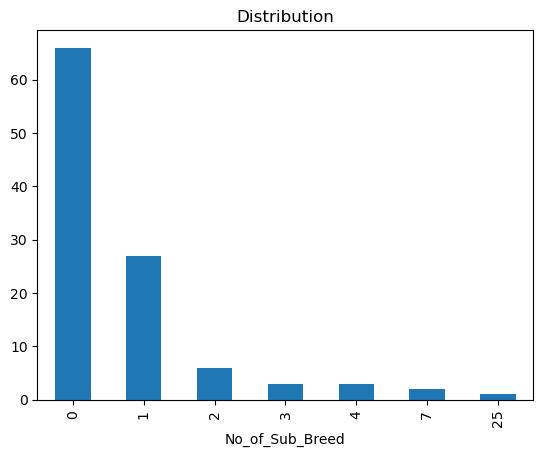

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.title('Distribution')
df['No_of_Sub_Breed'].value_counts().plot(kind='bar')
plt.show()

### Here we can see that breeds that has no sub breeds are highest and the breed that has only 1 sub breed is the 2nd highest 

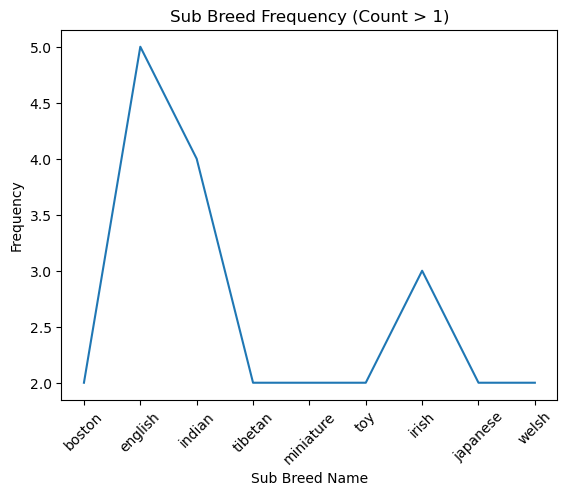

In [92]:
filtered_sub = {k: v for k, v in sub.items() if v > 1}

x = list(filtered_sub.keys())
y = list(filtered_sub.values())

plt.figure()
plt.plot(x, y)

plt.xticks(rotation=45)
plt.xlabel("Sub Breed Name")
plt.ylabel("Frequency")
plt.title("Sub Breed Frequency (Count > 1)")

plt.show()

### In this distribution chart most common sub breed among all the dog breeds

# Conclusion

## In this project, breed data was extracted from the public API provided by Dog CEO and transformed into a structured pandas DataFrame for analysis.

Key Findings

1️⃣ Majority of breeds do not have sub-breeds
The distribution shows that most dog breeds have zero sub-classifications.

2️⃣ Few breeds have high subtype diversity
A small subset of breeds contains multiple sub-breeds, indicating deeper classification layers.

3️⃣ Recurring naming patterns
Common sub-breed labels such as geographic indicators (e.g., "indian", "english") and size descriptors (e.g., "miniature", "toy") appear across multiple breeds.